In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [38]:
# basic preprocessing - removing irrelevant columns
gdp = pd.read_excel('NY_GDP_PCAP (3).xlsx')
infant = pd.read_excel('SH_DYN_IMRT (1).xlsx')
maternal = pd.read_excel('SH_STA_MORT.xlsx')
maternal = maternal.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Age', 'Freq', 'Location', 'Reporting Type', 'Sex', 'Units'])
gdp = gdp.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Observation Status', 'Reporting Type', 'Units'])
infant = infant.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Reporting Type', 'Units'])

# filter infant to double sex

infant = infant[infant['Sex'] == 'BOTHSEX']

# gdp: Annual growth rate of real GDP per capita (%)
# maternal: Maternal mortality ratio (modeled estimate, per 100,000 live births)
# infant: measures Infant mortality rate (deaths per 1,000 live births), units is per 1000 live births

In [39]:
# Convert datasets from wide to long

years_now = ['2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020']
maternal_long = pd.melt(maternal, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='Maternal Mortality Ratio per 100,000 Live Births')
countries_mat = list(maternal_long['GeoAreaName'].unique())

In [40]:
import pandas as pd
import numpy as np
#import yfinance as yf
import matplotlib as plt



country_to_continent = {
    # Africa
    "Algeria": "Africa",
    "Angola": "Africa",
    "Benin": "Africa",
    "Botswana": "Africa",
    "Burkina Faso": "Africa",
    "Burundi": "Africa",
    "Cabo Verde": "Africa",
    "Cameroon": "Africa",
    "Central African Republic": "Africa",
    "Chad": "Africa",
    "Comoros": "Africa",
    "Congo": "Africa",
    "Democratic Republic of the Congo": "Africa",
    "Côte d'Ivoire": "Africa",
    "Djibouti": "Africa",
    "Egypt": "Africa",
    "Equatorial Guinea": "Africa",
    "Eritrea": "Africa",
    "Eswatini": "Africa",
    "Ethiopia": "Africa",
    "Gabon": "Africa",
    "Gambia": "Africa",
    "Ghana": "Africa",
    "Guinea": "Africa",
    "Guinea-Bissau": "Africa",
    "Kenya": "Africa",
    "Lesotho": "Africa",
    "Liberia": "Africa",
    "Libya": "Africa",
    "Madagascar": "Africa",
    "Malawi": "Africa",
    "Mali": "Africa",
    "Mauritania": "Africa",
    "Mauritius": "Africa",
    "Morocco": "Africa",
    "Mozambique": "Africa",
    "Namibia": "Africa",
    "Niger": "Africa",
    "Nigeria": "Africa",
    "Rwanda": "Africa",
    "São Tomé and Príncipe": "Africa",
    "Senegal": "Africa",
    "Seychelles": "Africa",
    "Sierra Leone": "Africa",
    "Somalia": "Africa",
    "South Africa": "Africa",
    "South Sudan": "Africa",
    "Sudan": "Africa",
    "Tanzania": "Africa",
    "Togo": "Africa",
    "Tunisia": "Africa",
    "Uganda": "Africa",
    "Zambia": "Africa",
    "Zimbabwe": "Africa",
    "Central African Republic": "Africa",
    "Eastern Africa": "Africa",

    # Asia
    "Afghanistan": "Asia",
    "Armenia": "Asia",
    "Azerbaijan": "Asia",
    "Bahrain": "Asia",
    "Bangladesh": "Asia",
    "Bhutan": "Asia",
    "Brunei": "Asia",
    "Cambodia": "Asia",
    "China": "Asia",
    "Cyprus": "Asia",
    "Georgia": "Asia",
    "India": "Asia",
    "Indonesia": "Asia",
    "Iran (Islamic Republic of)": "Asia",
    "Iraq": "Asia",
    "Israel": "Asia",
    "Japan": "Asia",
    "Jordan": "Asia",
    "Kazakhstan": "Asia",
    "Kuwait": "Asia",
    "Kyrgyzstan": "Asia",
    "Lao People's Democratic Republic": "Asia",
    "Lebanon": "Asia",
    "Malaysia": "Asia",
    "Maldives": "Asia",
    "Mongolia": "Asia",
    "Myanmar": "Asia",
    "Nepal": "Asia",
    "Oman": "Asia",
    "Pakistan": "Asia",
    "Palestine": "Asia",
    "Philippines": "Asia",
    "Qatar": "Asia",
    "Saudi Arabia": "Asia",
    "Singapore": "Asia",
    "Democratic People's Republic of Korea": "Asia",
    "Republic of Korea": "Asia",
    "Sri Lanka": "Asia",
    "Syria": "Asia",
    "Taiwan": "Asia",
    "Tajikistan": "Asia",
    "Thailand": "Asia",
    "Timor-Leste": "Asia",
    "Türkiye": "Asia",
    "Turkmenistan": "Asia",
    "United Arab Emirates": "Asia",
    "Uzbekistan": "Asia",
    "Viet Nam": "Asia",
    "Yemen": "Asia",
    "Central and Southern Asia": "Asia",
    "Central Asia": "Asia",
    "Eastern and South-Eastern Asia": "Asia",
    "Eastern Asia": "Asia",

    # Europe
    "Albania": "Europe",
    "Andorra": "Europe",
    "Austria": "Europe",
    "Belarus": "Europe",
    "Belgium": "Europe",
    "Bosnia and Herzegovina": "Europe",
    "Bulgaria": "Europe",
    "Croatia": "Europe",
    "Czech Republic": "Europe",
    "Denmark": "Europe",
    "Estonia": "Europe",
    "Finland": "Europe",
    "France": "Europe",
    "Germany": "Europe",
    "Greece": "Europe",
    "Hungary": "Europe",
    "Iceland": "Europe",
    "Ireland": "Europe",
    "Italy": "Europe",
    "Kosovo": "Europe",
    "Latvia": "Europe",
    "Liechtenstein": "Europe",
    "Lithuania": "Europe",
    "Luxembourg": "Europe",
    "Malta": "Europe",
    "Moldova": "Europe",
    "Monaco": "Europe",
    "Montenegro": "Europe",
    "Netherlands": "Europe",
    "North Macedonia": "Europe",
    "Norway": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Romania": "Europe",
    "Russian Federation": "Europe",
    "San Marino": "Europe",
    "Serbia": "Europe",
    "Slovakia": "Europe",
    "Slovenia": "Europe",
    "Spain": "Europe",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Ukraine": "Europe",
    "United Kingdom of Great Britain and Northern Ireland": "Europe",
    "Vatican City": "Europe",
    "Western Europe": "Europe",
    "Eastern Europe": "Europe",

    # North America
    "Antigua and Barbuda": "North America",
    "Bahamas": "North America",
    "Barbados": "North America",
    "Belize": "North America",
    "Canada": "North America",
    "Costa Rica": "North America",
    "Cuba": "North America",
    "Dominica": "North America",
    "Dominican Republic": "North America",
    "El Salvador": "North America",
    "Grenada": "North America",
    "Guatemala": "North America",
    "Haiti": "North America",
    "Honduras": "North America",
    "Jamaica": "North America",
    "Mexico": "North America",
    "Nicaragua": "North America",
    "Panama": "North America",
    "Saint Kitts and Nevis": "North America",
    "Saint Lucia": "North America",
    "Saint Vincent and the Grenadines": "North America",
    "Trinidad and Tobago": "North America",
    "United States of America": "North America",
    "Caribbean": "North America",
    "Central America": "North America",

   

    # South America
    "Argentina": "South America",
    "Bolivia": "South America",
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",
    "Ecuador": "South America",
    "Guyana": "South America",
    "Paraguay": "South America",
    "Peru": "South America",
    "Suriname": "South America",
    "Uruguay": "South America",
    "Venezuela": "South America",

    # Oceania
    "Australia": "Oceania",
    "Fiji": "Oceania",
    "Kiribati": "Oceania",
    "Marshall Islands": "Oceania",
    "Micronesia": "Oceania",
    "Nauru": "Oceania",
    "New Zealand": "Oceania",
    "Palau": "Oceania",
    "Papua New Guinea": "Oceania",
    "Samoa": "Oceania",
    "Solomon Islands": "Oceania",
    "Tonga": "Oceania",
    "Tuvalu": "Oceania",
    "Vanuatu": "Oceania",

    # Antarctica
    # Note: Antarctica has no countries, but several territories and research stations.
}


# Convert datasets from wide to long

years_now = ['2000', '2001', '2002', '2003', '2004', '2005', '2006',
'2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
'2016', '2017', '2018', '2019', '2020']

maternal_long = pd.melt(maternal, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='maternal_morality_ratio')

maternal_long['Continent'] = maternal_long['GeoAreaName'].map(country_to_continent)
maternal_long = maternal_long.dropna(subset=['Continent'])
#print(maternal_long)

In [41]:
maternal_long.to_csv("maternal_mortality_ratio.csv", index=False)

In [42]:
import pandas as pd
import plotly.express as px

fig = px.choropleth(
    maternal_long,
    locations='GeoAreaName',
    locationmode='country names',
    color='maternal_morality_ratio',
    hover_name='GeoAreaName',
    animation_frame='Year',  # Optional: to make it time-animated
    color_continuous_scale='Reds',
    title='Global Maternal Mortality by Country and Year'
)

fig.show()

In [30]:
maternal_long.groupby(['Continent', 'Year'])

In [31]:
avg_mmr = maternal_long.groupby(['Continent', 'Year'])['maternal_morality_ratio'].mean().reset_index()

# Optionally, rename for clarity
avg_mmr.rename(columns={'maternal_morality_ratio': 'avg_maternal_mortality_ratio'}, inplace=True)

In [43]:
avg_mmr.to_csv("continent_mortality_data.csv", index=False)

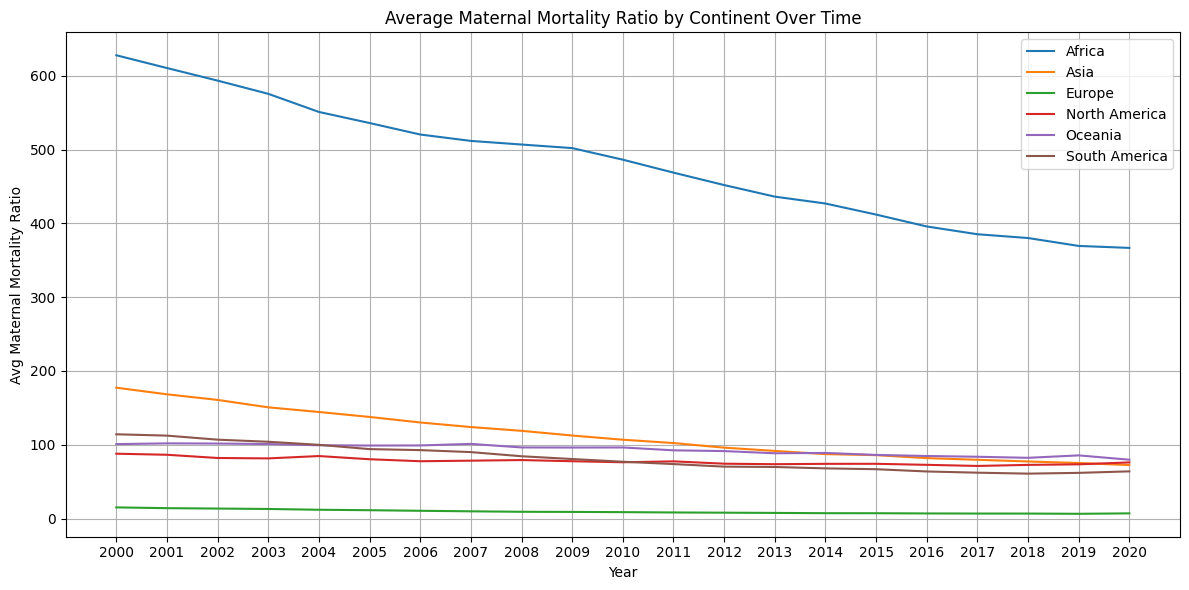

In [37]:
plt.figure(figsize=(12, 6))

# Loop through each continent and plot
for continent in avg_mmr['Continent'].unique():
    continent_data = avg_mmr[avg_mmr['Continent'] == continent]
    plt.plot(continent_data['Year'], continent_data['avg_maternal_mortality_ratio'], label=continent)

# Step 3: Customize the plot
plt.title('Average Maternal Mortality Ratio by Continent Over Time')
plt.xlabel('Year')
plt.ylabel('Avg Maternal Mortality Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
maternal_long

,GeoAreaName,Year,maternal_morality_ratio,Continent
0,Afghanistan,2000,1346.14410,Asia
2,Albania,2000,14.32641,Europe
3,Algeria,2000,159.17568,Africa
5,Angola,2000,859.92091,Africa
6,Antigua and Barbuda,2000,51.29847,North America
...,...,...,...,...
4717,Viet Nam,2020,45.53003,Asia
4720,Western Europe,2020,5.92971,Europe
4722,Yemen,2020,183.39972,Asia
4723,Zambia,2020,134.66542,Africa
